# Embedding Models Evaluation

This notebook evaluates the performance of text embedding (halong) and image embedding (dinov2) models used in the KK Bookstore AI application. We'll:

1. Mount Google Drive to access the data and source code
2. Set up the necessary dependencies
3. Load the models and datasets
4. Evaluate each model independently
5. Generate evaluation metrics for the report

## 1. Mount Google Drive and Setup Environment

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set paths
import os
import sys

# Path to the app directory
APP_DIR = '/content/drive/MyDrive/KLTN_SRC'
# Path to the data directory
DATA_DIR = '/content/drive/MyDrive/KLTN_DATA'

# Add app directory to Python path
sys.path.append(APP_DIR)

# Check if directories exist
print(f"App directory exists: {os.path.exists(APP_DIR)}")
print(f"Data directory exists: {os.path.exists(DATA_DIR)}")

Mounted at /content/drive
App directory exists: True
Data directory exists: True


## 2. Install Dependencies

In [2]:
# Install required packages
!pip install sentence-transformers torch chromadb transformers evaluate scikit-learn matplotlib seaborn pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 4.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 77.4 MB/s 

## 3. Import Libraries

In [3]:
import torch
import json
import chromadb
import os
import base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer

## 4. Load Text and Image Embedding Functions

We'll recreate the embedding generators based on your original code but with additional evaluation capabilities.

In [4]:
# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [14]:
# Define Text Embedding Generator with evaluation capabilities
class TextEmbeddingGenerator:
    def __init__(self):
        # Use exactly the same model name as your actual implementation
        self.model_name = "hiieu/halong_embedding"  # The model you're using in production
        print(f"Loading text embedding model: {self.model_name}")
        self.model = SentenceTransformer(self.model_name)
        self.model.to(device)
        self.embedding_dimension = self.model.get_sentence_embedding_dimension()
        print(f"Text embedding dimension: {self.embedding_dimension}")

        # IMPORTANT: Verify the dimension matches what we expect (768)
        if self.embedding_dimension != 768:
            print(f"WARNING: Expected embedding dimension to be 768, but got {self.embedding_dimension}")
            print("This could cause dimension mismatch errors if not corrected throughout the notebook")

    def generate_text_embedding(self, text):
        """Generate embedding for text input"""
        if isinstance(text, str):
            text = [text]

        # Convert to numpy array to ensure consistent dimensionality
        embedding = self.model.encode(text)

        # If there's only one embedding, return it as a list
        if len(embedding) == 1:
            return embedding[0].tolist()
        return embedding.tolist()

    def batch_generate_embeddings(self, texts):
        """Generate embeddings for a batch of texts"""
        embeddings = self.model.encode(texts)
        return embeddings

    def evaluate_similarity(self, text1, text2):
        """Evaluate similarity between two texts"""
        emb1 = self.model.encode([text1])[0]
        emb2 = self.model.encode([text2])[0]
        similarity = cosine_similarity([emb1], [emb2])[0][0]
        return similarity

In [15]:
# Define Image Embedding Generator with evaluation capabilities
class ImageEmbeddingGenerator:
    def __init__(self):
        # Using DINOv2 model for image embeddings - match your production code
        print("Loading image embedding model: DINOv2")

        # Constants matching your implementation in image_embedding.py
        MODEL_REPOSITORY = "facebookresearch/dinov2"
        MODEL_NAME = "dinov2_vitl14"
        print(f"Loading image model: {MODEL_REPOSITORY}/{MODEL_NAME}")

        # Using the torch.hub approach as in your implementation
        self.model = torch.hub.load(
            repo_or_dir=MODEL_REPOSITORY,
            model=MODEL_NAME,
            pretrained=True,
            force_reload=False
        ).to(device)

        # Get embedding dimension
        # Note: dinov2_vitl14 has 1024 dimensions instead of 768 in dinov2-base
        self.embedding_dimension = 1024  # dinov2_vitl14 dimension
        print(f"Image embedding dimension: {self.embedding_dimension}")

        # Define transformation pipeline for images matching your implementation
        self.transform = T.Compose([
            T.ToTensor(),
            T.Resize(244),
            T.CenterCrop(224),
            T.Normalize([0.5], [0.5])
        ])

    def base64_to_image(self, base64_str):
        """Convert base64 string to PIL Image"""
        img_data = base64.b64decode(base64_str)
        return Image.open(BytesIO(img_data))

    def generate_image_embedding(self, base64_image):
        """Generate embedding for base64 image input"""
        image = self.base64_to_image(base64_image)
        image = image.convert('RGB')  # Ensure image is RGB

        # Apply transformations similar to your implementation
        transformed_image = self.transform(image).unsqueeze(0).to(device)

        # Generate embedding
        with torch.no_grad():
            embedding_tensor = self.model(transformed_image)

        return embedding_tensor[0].cpu().detach().numpy().tolist()

    def generate_embedding_from_path(self, image_path):
        """Generate embedding directly from an image path"""
        with open(image_path, 'rb') as f:
            img_data = f.read()
            base64_str = base64.b64encode(img_data).decode('utf-8')

        return self.generate_image_embedding(base64_str)

    def evaluate_similarity(self, image_path1, image_path2):
        """Evaluate similarity between two images"""
        emb1 = self.generate_embedding_from_path(image_path1)
        emb2 = self.generate_embedding_from_path(image_path2)
        similarity = cosine_similarity([emb1], [emb2])[0][0]
        return similarity

## 5. Data Loading and Preparation

Let's load the data from your Google Drive location.

In [8]:
# Load text data
text_data_path = os.path.join(DATA_DIR, 'output', 'product_injected_categories.json')
with open(text_data_path, 'r', encoding='utf-8') as file:
    text_data = json.load(file)

print(f"Loaded {len(text_data)} book entries")
print(f"Sample book: {text_data[0]['Name']}")

# Define images directory
image_data_dir = os.path.join(DATA_DIR, 'output', 'images')
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')

# Count images
image_count = 0
for subdir, _, files in os.walk(image_data_dir):
    for file in files:
        if file.lower().endswith(image_extensions):
            image_count += 1

print(f"Found {image_count} images")

Loaded 2351 book entries
Sample book: Hiệu Ứng Chim Mồi
Found 14332 images


## 6. Text Embedding Model Evaluation

In [ ]:
# Initialize text embedding model
text_embedding = TextEmbeddingGenerator()

# Prepare text samples for evaluation (use a larger subset for more reliable evaluation)
eval_size = min(500, len(text_data))  # Increased from 100 to 500
print(f"Using {eval_size} out of {len(text_data)} available books for evaluation")

eval_texts = []
book_categories = []

for i, item in enumerate(text_data[:eval_size]):
    text = f"Tên sách: {item['Name']}\n" + f"Nội dung sách: {item['Description']}"
    eval_texts.append(text)
    # Extract category for clustering evaluation
    if 'CategoryName' in item:
        book_categories.append(item['CategoryName'])
    elif 'Category' in item and isinstance(item['Category'], dict) and 'DisplayName' in item['Category']:
        book_categories.append(item['Category']['DisplayName'])
    else:
        book_categories.append('Unknown')

# Generate embeddings for all evaluation texts
print(f"Generating embeddings for {len(eval_texts)} text samples...")
text_embeddings = text_embedding.batch_generate_embeddings(eval_texts)

Loading text embedding model: hiieu/halong_embedding
Text embedding dimension: 768
Generating embeddings for 100 text samples...


### 6.1 Evaluate Text Model with Clustering Quality

In [19]:
# Convert categories to numerical values for evaluation
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

# Filter for entries with known categories
valid_indices = [i for i, cat in enumerate(book_categories) if cat != 'Unknown']
valid_categories = [book_categories[i] for i in valid_indices]
valid_embeddings = text_embeddings[valid_indices]

if len(set(valid_categories)) > 1 and len(valid_categories) > 10:
    # Encode the categories
    encoded_categories = label_encoder.fit_transform(valid_categories)

    # Calculate silhouette score (measure of cluster quality)
    silhouette_avg = silhouette_score(valid_embeddings, encoded_categories)
    print(f"Silhouette Score: {silhouette_avg:.4f}")

    # Calculate Davies-Bouldin index (lower is better)
    from sklearn.metrics import davies_bouldin_score
    db_index = davies_bouldin_score(valid_embeddings, encoded_categories)
    print(f"Davies-Bouldin Index: {db_index:.4f}")

    # Calculate Calinski-Harabasz score (higher is better)
    from sklearn.metrics import calinski_harabasz_score
    ch_score = calinski_harabasz_score(valid_embeddings, encoded_categories)
    print(f"Calinski-Harabasz Score: {ch_score:.4f}")
else:
    print("Not enough categories or samples for clustering evaluation")

Silhouette Score: 0.1110
Davies-Bouldin Index: 2.3489
Calinski-Harabasz Score: 7.7030


### 6.2 Intra-Category and Inter-Category Similarity Analysis

Average intra-category similarity: 0.4132
Average inter-category similarity: 0.2361


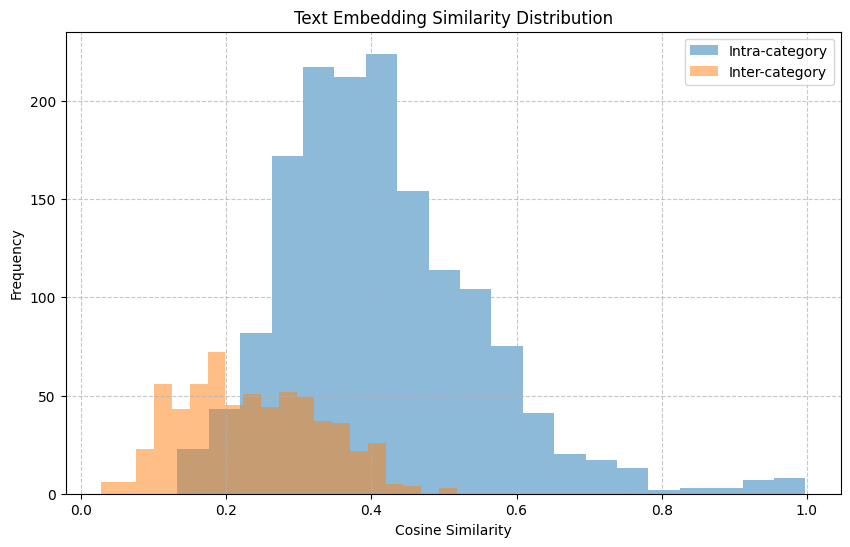

In [20]:
# Calculate within-category and between-category similarities
if len(set(valid_categories)) > 1:
    category_to_indices = {}
    for i, category in enumerate(valid_categories):
        if category not in category_to_indices:
            category_to_indices[category] = []
        category_to_indices[category].append(i)

    # Calculate intra-category similarity (within same category)
    intra_category_similarities = []
    for category, indices in category_to_indices.items():
        if len(indices) > 1:  # Need at least 2 items to compare
            embeddings = valid_embeddings[indices]
            # Calculate all pairwise similarities within category
            similarity_matrix = cosine_similarity(embeddings)
            # Extract upper triangle values (excluding diagonal)
            upper_tri_indices = np.triu_indices(similarity_matrix.shape[0], k=1)
            similarities = similarity_matrix[upper_tri_indices]
            intra_category_similarities.extend(similarities)

    # Calculate inter-category similarity (between different categories)
    inter_category_similarities = []
    categories = list(category_to_indices.keys())
    for i in range(len(categories)):
        for j in range(i+1, len(categories)):
            cat1_indices = category_to_indices[categories[i]]
            cat2_indices = category_to_indices[categories[j]]

            # Get sample indices for comparison (max 10 pairs to avoid excessive computation)
            sample_size = min(10, len(cat1_indices), len(cat2_indices))
            cat1_sample = np.random.choice(cat1_indices, sample_size, replace=False)
            cat2_sample = np.random.choice(cat2_indices, sample_size, replace=False)

            # Calculate similarities between sampled pairs
            for idx1 in cat1_sample:
                for idx2 in cat2_sample:
                    sim = cosine_similarity([valid_embeddings[idx1]], [valid_embeddings[idx2]])[0][0]
                    inter_category_similarities.append(sim)

    print(f"Average intra-category similarity: {np.mean(intra_category_similarities):.4f}")
    print(f"Average inter-category similarity: {np.mean(inter_category_similarities):.4f}")

    # Plot similarity distributions
    plt.figure(figsize=(10, 6))
    plt.hist(intra_category_similarities, alpha=0.5, bins=20, label='Intra-category')
    plt.hist(inter_category_similarities, alpha=0.5, bins=20, label='Inter-category')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Frequency')
    plt.title('Text Embedding Similarity Distribution')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Not enough categories for similarity analysis")

## 7. Image Embedding Model Evaluation

In [ ]:
# Initialize image embedding model
image_embedding = ImageEmbeddingGenerator()

# Function to convert image to base64
def image_to_base64(image_path):
    with open(image_path, 'rb') as image_file:
        encoded_string = base64.b64encode(image_file.read()).decode('utf-8')
    return encoded_string

# Find image samples for evaluation (using a larger subset)
image_paths = []
image_product_ids = []
max_images = 200  # Increased from 50 to 200 for better evaluation

print("Collecting image paths for evaluation...")
for subdir, _, files in os.walk(image_data_dir):
    if len(image_paths) >= max_images:
        break

    product_id = os.path.basename(subdir)[5:] if os.path.basename(subdir).startswith('item_') else os.path.basename(subdir)

    for file in files:
        if file.lower().endswith(image_extensions):
            if len(image_paths) >= max_images:
                break
            full_path = os.path.join(subdir, file)
            image_paths.append(full_path)
            image_product_ids.append(product_id)

print(f"Collected {len(image_paths)} images for evaluation out of {image_count} available images")

# Count unique products to ensure we have good diversity
unique_product_count = len(set(image_product_ids))
print(f"Representing {unique_product_count} unique products")

Loading image embedding model: DINOv2
Loading image model: facebookresearch/dinov2/dinov2_vitl14


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitl14/dinov2_vitl14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitl14_pretrain.pth
100%|██████████| 1.13G/1.13G [00:18<00:00, 65.3MB/s]


Image embedding dimension: 1024
Collected 50 images for evaluation


In [27]:
# Generate embeddings for all images
print("Generating image embeddings...")
image_embeddings = []

for path in image_paths:
    embedding = image_embedding.generate_embedding_from_path(path)
    image_embeddings.append(embedding)

image_embeddings = np.array(image_embeddings)
print(f"Generated embeddings with shape {image_embeddings.shape}")

Generating image embeddings...
Generated embeddings with shape (50, 1024)


### 7.1 Image Similarity Analysis by Product

Unique products: 9
Average intra-product similarity: 0.4127
Average inter-product similarity: 0.1564


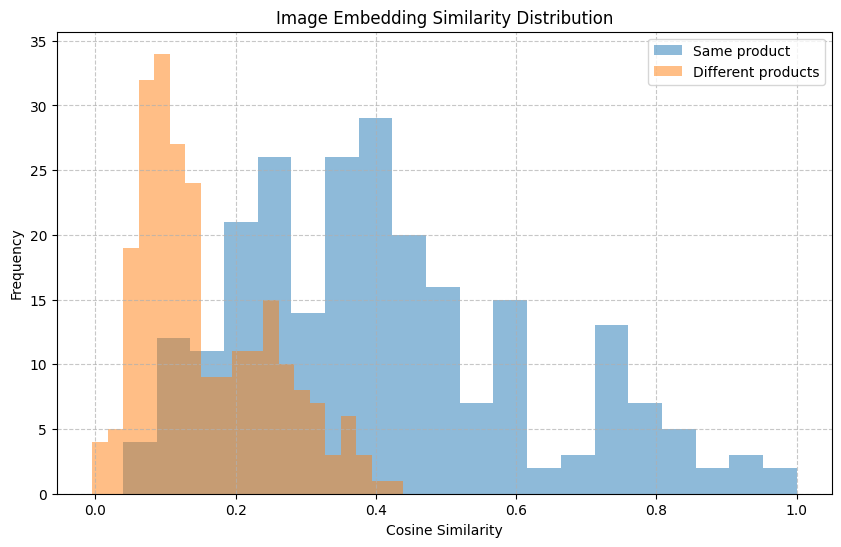

In [28]:
# Calculate within-product and between-product similarities
unique_products = set(image_product_ids)
print(f"Unique products: {len(unique_products)}")

if len(unique_products) > 1:
    # Group images by product ID
    product_to_indices = {}
    for i, product_id in enumerate(image_product_ids):
        if product_id not in product_to_indices:
            product_to_indices[product_id] = []
        product_to_indices[product_id].append(i)

    # Calculate intra-product similarity (images of the same product)
    intra_product_similarities = []
    for product, indices in product_to_indices.items():
        if len(indices) > 1:  # Need at least 2 images to compare
            product_embeddings = image_embeddings[indices]
            # Calculate all pairwise similarities within product
            similarity_matrix = cosine_similarity(product_embeddings)
            # Extract upper triangle values (excluding diagonal)
            upper_tri_indices = np.triu_indices(similarity_matrix.shape[0], k=1)
            similarities = similarity_matrix[upper_tri_indices]
            intra_product_similarities.extend(similarities)

    # Calculate inter-product similarity (between different products)
    inter_product_similarities = []
    products = list(product_to_indices.keys())
    for i in range(len(products)):
        for j in range(i+1, len(products)):
            prod1_indices = product_to_indices[products[i]]
            prod2_indices = product_to_indices[products[j]]

            # Get sample indices for comparison
            sample_size = min(5, len(prod1_indices), len(prod2_indices))
            prod1_sample = np.random.choice(prod1_indices, sample_size, replace=False)
            prod2_sample = np.random.choice(prod2_indices, sample_size, replace=False)

            # Calculate similarities
            for idx1 in prod1_sample:
                for idx2 in prod2_sample:
                    sim = cosine_similarity([image_embeddings[idx1]], [image_embeddings[idx2]])[0][0]
                    inter_product_similarities.append(sim)

    print(f"Average intra-product similarity: {np.mean(intra_product_similarities):.4f}")
    print(f"Average inter-product similarity: {np.mean(inter_product_similarities):.4f}")

    # Plot similarity distributions
    plt.figure(figsize=(10, 6))
    plt.hist(intra_product_similarities, alpha=0.5, bins=20, label='Same product')
    plt.hist(inter_product_similarities, alpha=0.5, bins=20, label='Different products')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Frequency')
    plt.title('Image Embedding Similarity Distribution')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Not enough unique products for similarity analysis")

### 7.2 Image Retrieval Evaluation


Query Image: img_1356_13907.jpeg (Product ID: prod_1356)
Top 5 most similar images:
1. img_1356_13908.jpeg (Product ID: prod_1356, Same product: True, Similarity: 0.9104)
2. img_1356_13942.jpeg (Product ID: prod_1356, Same product: True, Similarity: 0.7232)
3. img_1355_13906.jpeg (Product ID: prod_1355, Same product: False, Similarity: 0.3572)
4. img_1355_13901.jpeg (Product ID: prod_1355, Same product: False, Similarity: 0.3299)
5. img_1355_13904.jpeg (Product ID: prod_1355, Same product: False, Similarity: 0.3299)


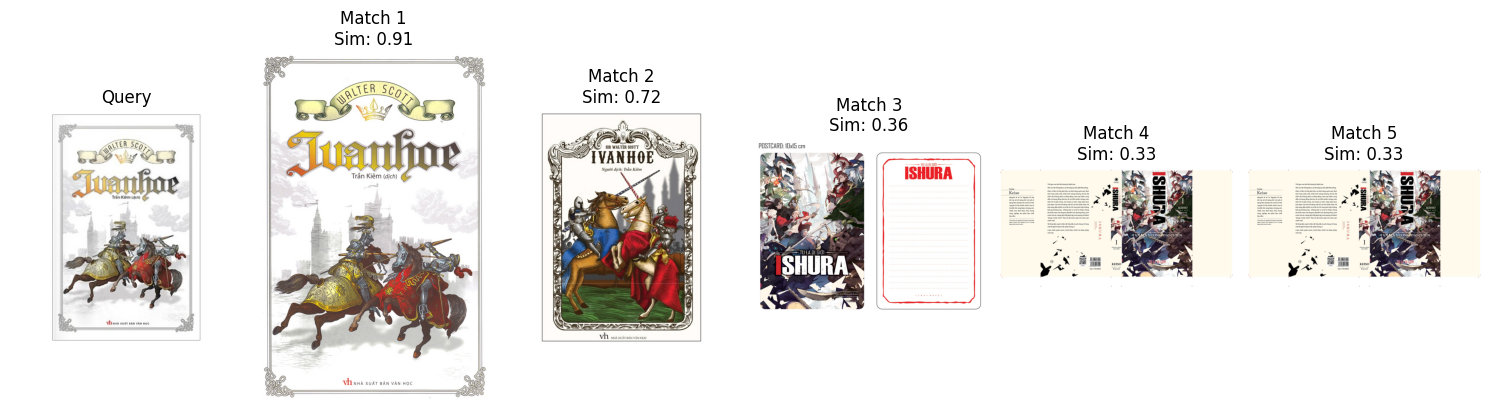


Query Image: img_1353_13868.jpeg (Product ID: prod_1353)
Top 5 most similar images:
1. img_1360_13992.jpeg (Product ID: prod_1360, Same product: False, Similarity: 0.4631)
2. img_1360_13996.jpeg (Product ID: prod_1360, Same product: False, Similarity: 0.4429)
3. img_1360_13983.jpeg (Product ID: prod_1360, Same product: False, Similarity: 0.4167)
4. img_1360_13984.jpeg (Product ID: prod_1360, Same product: False, Similarity: 0.4124)
5. img_1360_13994.jpeg (Product ID: prod_1360, Same product: False, Similarity: 0.3993)


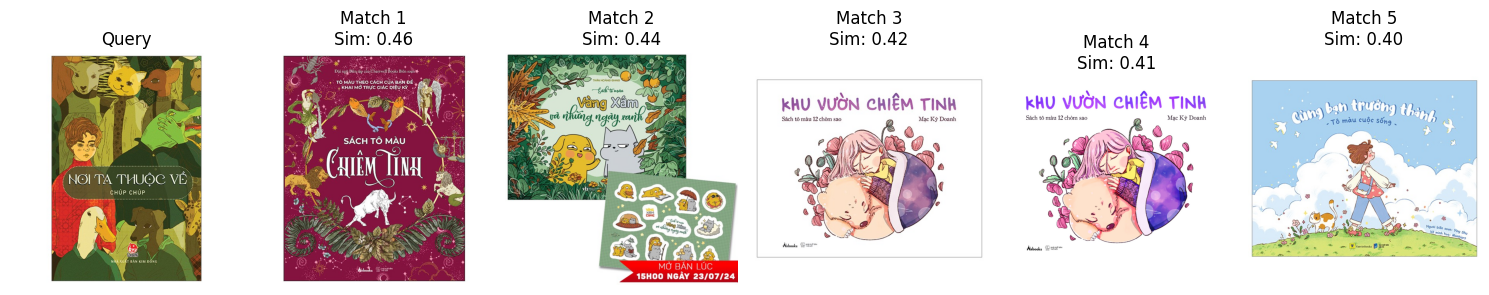


Query Image: img_1360_13989.jpeg (Product ID: prod_1360)
Top 5 most similar images:
1. img_1360_13992.jpeg (Product ID: prod_1360, Same product: True, Similarity: 0.4935)
2. img_1360_13996.jpeg (Product ID: prod_1360, Same product: True, Similarity: 0.4718)
3. img_1360_13990.jpeg (Product ID: prod_1360, Same product: True, Similarity: 0.4109)
4. img_1360_14001.jpeg (Product ID: prod_1360, Same product: True, Similarity: 0.3922)
5. img_1356_13943.jpeg (Product ID: prod_1356, Same product: False, Similarity: 0.3897)


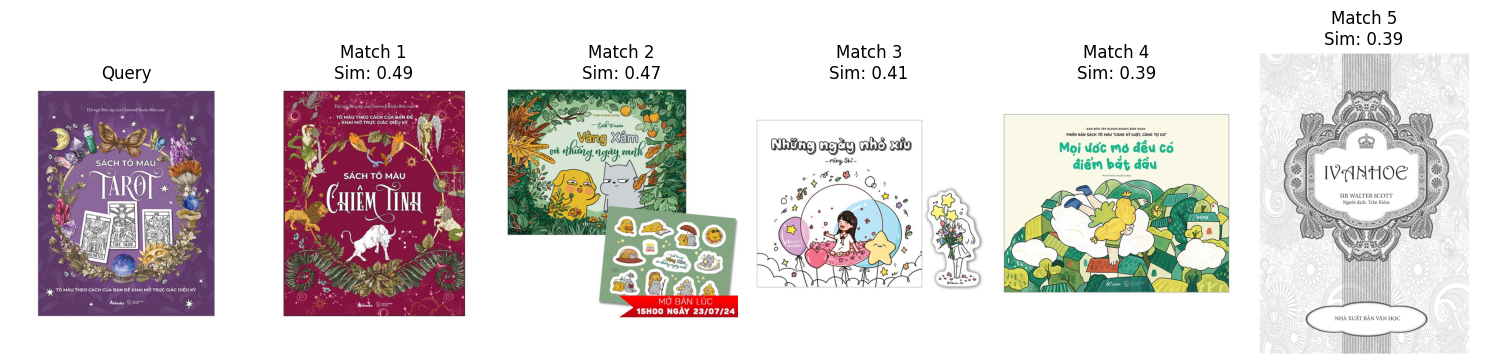


Query Image: img_1360_13990.jpeg (Product ID: prod_1360)
Top 5 most similar images:
1. img_1360_13995.jpeg (Product ID: prod_1360, Same product: True, Similarity: 0.5966)
2. img_1360_13983.jpeg (Product ID: prod_1360, Same product: True, Similarity: 0.5134)
3. img_1360_13994.jpeg (Product ID: prod_1360, Same product: True, Similarity: 0.5033)
4. img_1360_13996.jpeg (Product ID: prod_1360, Same product: True, Similarity: 0.5010)
5. img_1360_13985.jpeg (Product ID: prod_1360, Same product: True, Similarity: 0.4536)


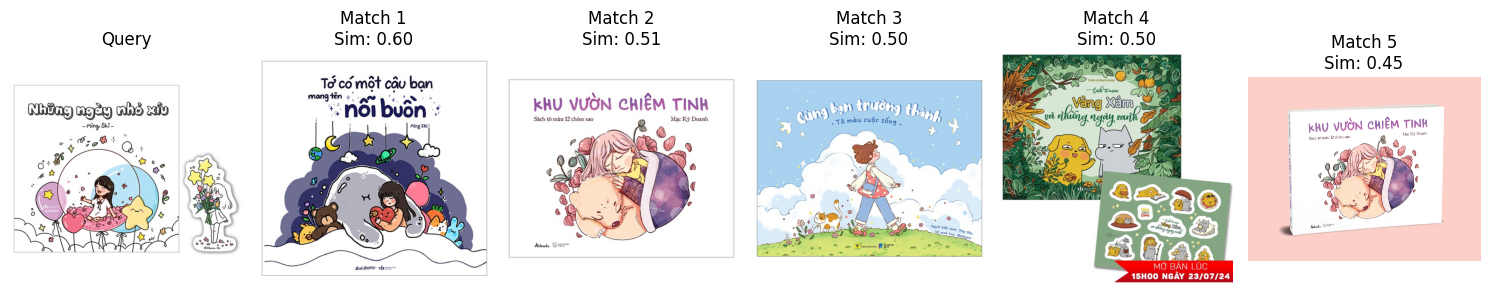


Query Image: img_1356_13942.jpeg (Product ID: prod_1356)
Top 5 most similar images:
1. img_1356_13908.jpeg (Product ID: prod_1356, Same product: True, Similarity: 0.7431)
2. img_1356_13907.jpeg (Product ID: prod_1356, Same product: True, Similarity: 0.7232)
3. img_1355_13906.jpeg (Product ID: prod_1355, Same product: False, Similarity: 0.4386)
4. img_1355_13902.jpeg (Product ID: prod_1355, Same product: False, Similarity: 0.3842)
5. img_1355_13899.jpeg (Product ID: prod_1355, Same product: False, Similarity: 0.3713)


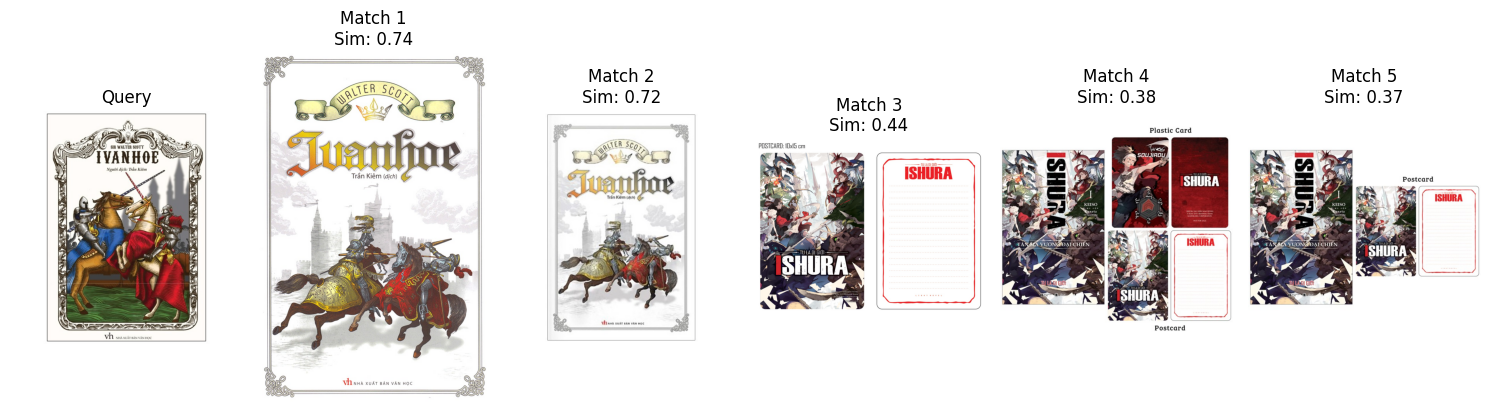

In [29]:
# Select a few query images
import random
num_queries = min(5, len(image_paths))
query_indices = random.sample(range(len(image_paths)), num_queries)

# For each query image, find the most similar images
for query_idx in query_indices:
    query_path = image_paths[query_idx]
    query_product = image_product_ids[query_idx]

    print(f"\nQuery Image: {os.path.basename(query_path)} (Product ID: {query_product})")
    print(f"Top 5 most similar images:")

    # Calculate similarities between query and all images
    similarities = cosine_similarity([image_embeddings[query_idx]], image_embeddings)[0]

    # Get indices of top 5 most similar images (excluding the query itself)
    # Sort all and then filter out the query image
    all_indices = np.argsort(similarities)[::-1]
    top_indices = [idx for idx in all_indices if idx != query_idx][:5]

    for rank, img_idx in enumerate(top_indices):
        img_path = image_paths[img_idx]
        img_product = image_product_ids[img_idx]
        is_same_product = img_product == query_product
        print(f"{rank+1}. {os.path.basename(img_path)} (Product ID: {img_product}, Same product: {is_same_product}, Similarity: {similarities[img_idx]:.4f})")

    # Optional: Display query image and top matches
    from IPython.display import display
    from PIL import Image

    # Create a figure with subplots
    plt.figure(figsize=(15, 6))

    # Display query image
    plt.subplot(1, 6, 1)
    plt.imshow(Image.open(query_path))
    plt.title('Query')
    plt.axis('off')

    # Display top 5 matches
    for i, idx in enumerate(top_indices):
        plt.subplot(1, 6, i+2)
        plt.imshow(Image.open(image_paths[idx]))
        plt.title(f'Match {i+1}\nSim: {similarities[idx]:.2f}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

## 8. Vector Database Querying Simulation

Let's simulate how the ChromaDB would be used for retrieval and evaluate the quality of search results.

In [30]:
# Create in-memory ChromaDB collections for evaluation
client = chromadb.EphemeralClient()

text_collection = client.create_collection(
    name="text_evaluation_db",
    metadata={"hnsw:space": "cosine"}
)

image_collection = client.create_collection(
    name="image_evaluation_db",
    metadata={"hnsw:space": "cosine"}
)

# Add sample text data to collection
print("Adding text data to vector database...")
for i, item in enumerate(text_data[:100]):  # Limit to 100 items for evaluation
    text = f"Tên sách: {item['Name']}\n" + f"Nội dung sách: {item['Description']}"
    embedding = text_embedding.generate_text_embedding(text)
    text_collection.add(
        embeddings=[embedding],
        documents=[text],
        metadatas=[{'id': str(item['Id']), 'name': item['Name'], 'description': item['Description']}],
        ids=[str(item['Id'])],
    )

# Add sample image data to collection
print("Adding image data to vector database...")
for i, image_path in enumerate(image_paths[:50]):  # Limit to 50 images
    product_id = image_product_ids[i]
    image_id = os.path.basename(image_path)[:-4]
    base64_image = image_to_base64(image_path)
    embedding = image_embedding.generate_embedding_from_path(image_path)

    image_collection.add(
        embeddings=[embedding],
        metadatas=[{'product_id': product_id, 'image_id': image_id}],
        ids=[image_id],
    )

Adding text data to vector database...
Adding image data to vector database...


### 8.1 Text Search Evaluation

In [31]:
# Evaluate text search with sample queries
print("Evaluating text search...")
test_text_queries = [
    "sách lập trình",
    "tiểu thuyết tình cảm",
    "sách cho trẻ em",
    "quản lý doanh nghiệp",
    "sách dạy nấu ăn"
]

for query in test_text_queries:
    print(f"\nQuery: '{query}'")

    # Generate embedding for query
    query_embedding = text_embedding.generate_text_embedding(query)

    # Query the collection
    results = text_collection.query(
        query_embeddings=[query_embedding],
        n_results=5,
        include=["metadatas", "distances"]
    )

    # Display results
    if results and 'metadatas' in results and len(results['metadatas']) > 0:
        for i, metadata in enumerate(results['metadatas'][0]):
            distance = results['distances'][0][i]
            similarity = 1 - distance  # Convert distance to similarity
            print(f"{i+1}. {metadata['name']} (Similarity: {similarity:.4f})")
    else:
        print("No results found")

Evaluating text search...

Query: 'sách lập trình'
1. Máy Tính Cầm Tay Bium ECD 704 - Morning Glory (Similarity: 0.3069)
2. Pentel Phấn Dầu PHN-50 (Similarity: 0.2962)
3. Bìa 20 Lá Trong Mờ - Thiết Kế Kiểu Paris Double A CH19312-EN (Similarity: 0.2782)
4. Bìa 20 Lá Trong Mờ - Double A - Thiết Kế Kiểu Paris - CH17112-EN (Similarity: 0.2776)
5. Máy Tính Deli EM10 (Similarity: 0.2765)

Query: 'tiểu thuyết tình cảm'
1. Quan Tình Trai (Similarity: 0.3313)
2. Chuyện Tình Ở Vườn Thú Hoshino (Similarity: 0.3296)
3. Sau Khi Thỏa Thuận Kết Hôn Cùng Ảnh Đế (Similarity: 0.3200)
4. Ngang Tàng (Similarity: 0.3031)
5. Bó Hoa 0 Phần Trăm (Similarity: 0.3007)

Query: 'sách cho trẻ em'
1. Thước Không Gãy Maped Fancy 30cm 245601 (Similarity: 0.3359)
2. Máy Tính 12 Số Để Bàn - Deli EM124-XD (Similarity: 0.3321)
3. Mực Lọ (Similarity: 0.3201)
4. Mực Máy Bấm (Similarity: 0.3191)
5. Mực Lông Dầu Horse (Similarity: 0.3109)

Query: 'quản lý doanh nghiệp'
1. HBR Onpoint 2021 (Similarity: 0.3034)
2. Hướng Dẫn Bà

### 8.2 Image Search Evaluation

Evaluating image search...

Query Image: img_1360_13997.jpeg (Product ID: prod_1360)
1. Image ID: img_1360_13997., Product ID: prod_1360 (Same product: True, Similarity: 1.0000)
2. Image ID: img_1360_13994., Product ID: prod_1360 (Same product: True, Similarity: 0.5876)
3. Image ID: img_1360_13996., Product ID: prod_1360 (Same product: True, Similarity: 0.4491)
4. Image ID: img_1360_14001., Product ID: prod_1360 (Same product: True, Similarity: 0.4195)
5. Image ID: img_1360_13995., Product ID: prod_1360 (Same product: True, Similarity: 0.4011)


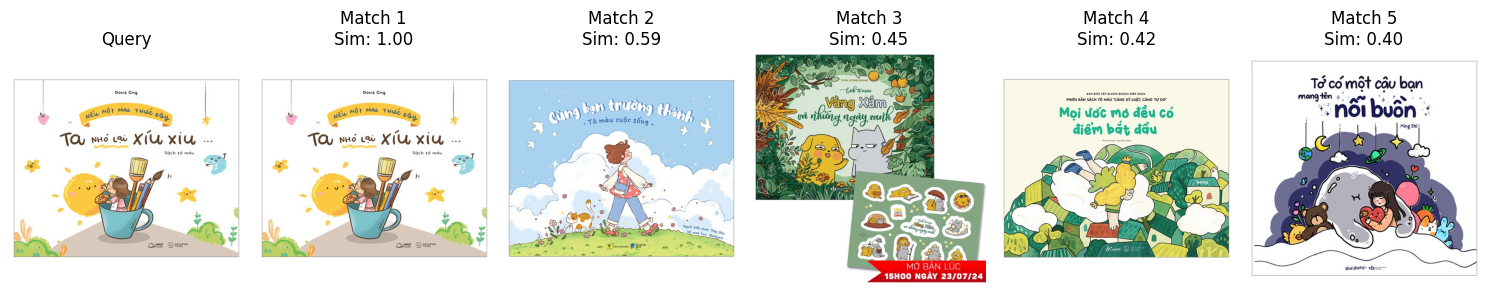


Query Image: img_1360_13993.jpeg (Product ID: prod_1360)
1. Image ID: img_1360_13993., Product ID: prod_1360 (Same product: True, Similarity: 1.0000)
2. Image ID: img_1360_13999., Product ID: prod_1360 (Same product: True, Similarity: 0.6457)
3. Image ID: img_1360_13996., Product ID: prod_1360 (Same product: True, Similarity: 0.4878)
4. Image ID: img_1360_13994., Product ID: prod_1360 (Same product: True, Similarity: 0.4806)
5. Image ID: img_1360_14001., Product ID: prod_1360 (Same product: True, Similarity: 0.4727)


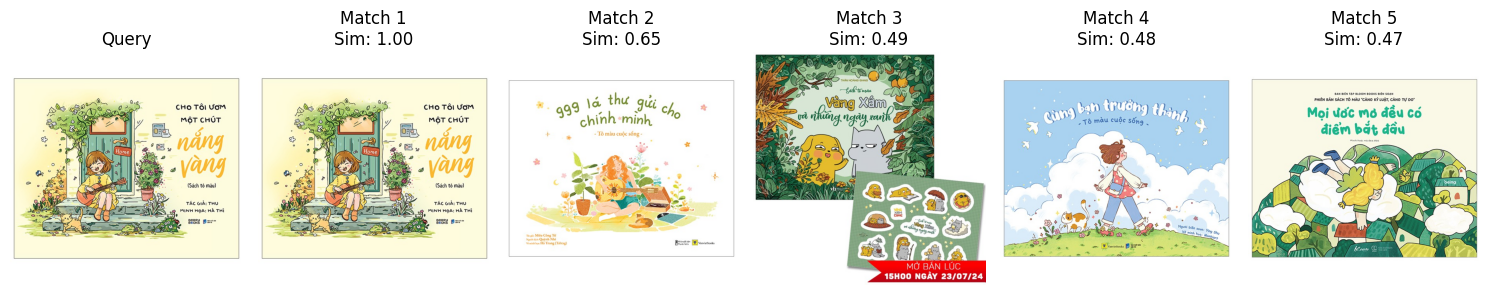


Query Image: img_1360_14000.jpeg (Product ID: prod_1360)
1. Image ID: img_1360_14000., Product ID: prod_1360 (Same product: True, Similarity: 1.0000)
2. Image ID: img_1360_13995., Product ID: prod_1360 (Same product: True, Similarity: 0.5535)
3. Image ID: img_1360_13994., Product ID: prod_1360 (Same product: True, Similarity: 0.5288)
4. Image ID: img_1360_14001., Product ID: prod_1360 (Same product: True, Similarity: 0.4406)
5. Image ID: img_1360_13996., Product ID: prod_1360 (Same product: True, Similarity: 0.4327)


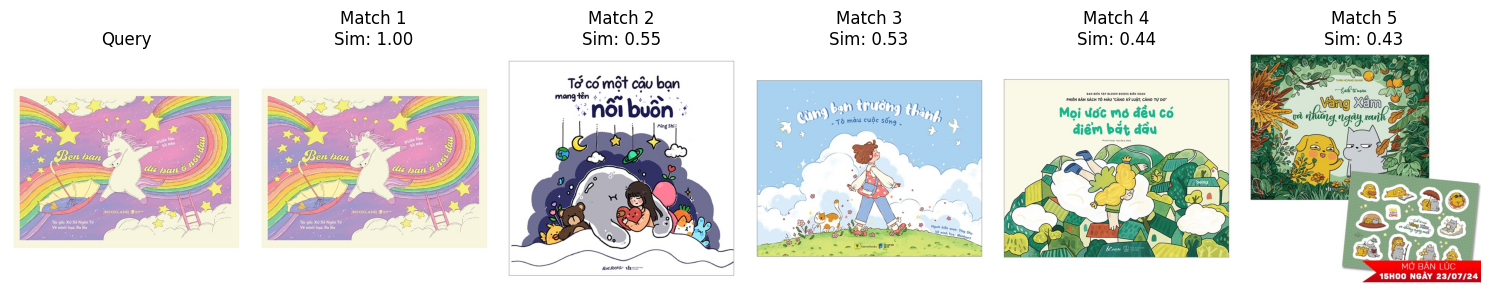


Query Image: img_1353_13878.jpeg (Product ID: prod_1353)
1. Image ID: img_1353_13878., Product ID: prod_1353 (Same product: True, Similarity: 1.0000)
2. Image ID: img_1353_13880., Product ID: prod_1353 (Same product: True, Similarity: 0.5356)
3. Image ID: img_1353_13877., Product ID: prod_1353 (Same product: True, Similarity: 0.4773)
4. Image ID: img_1353_13879., Product ID: prod_1353 (Same product: True, Similarity: 0.4447)
5. Image ID: img_1353_13876., Product ID: prod_1353 (Same product: True, Similarity: 0.4358)


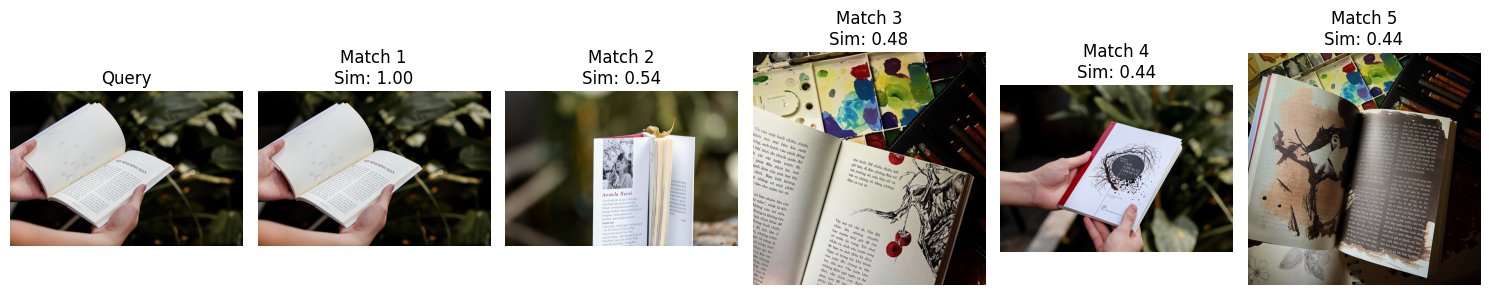


Query Image: img_1353_13868.jpeg (Product ID: prod_1353)
1. Image ID: img_1353_13868., Product ID: prod_1353 (Same product: True, Similarity: 1.0000)
2. Image ID: img_1360_13992., Product ID: prod_1360 (Same product: False, Similarity: 0.4631)
3. Image ID: img_1360_13996., Product ID: prod_1360 (Same product: False, Similarity: 0.4429)
4. Image ID: img_1360_13983., Product ID: prod_1360 (Same product: False, Similarity: 0.4167)
5. Image ID: img_1360_13984., Product ID: prod_1360 (Same product: False, Similarity: 0.4124)


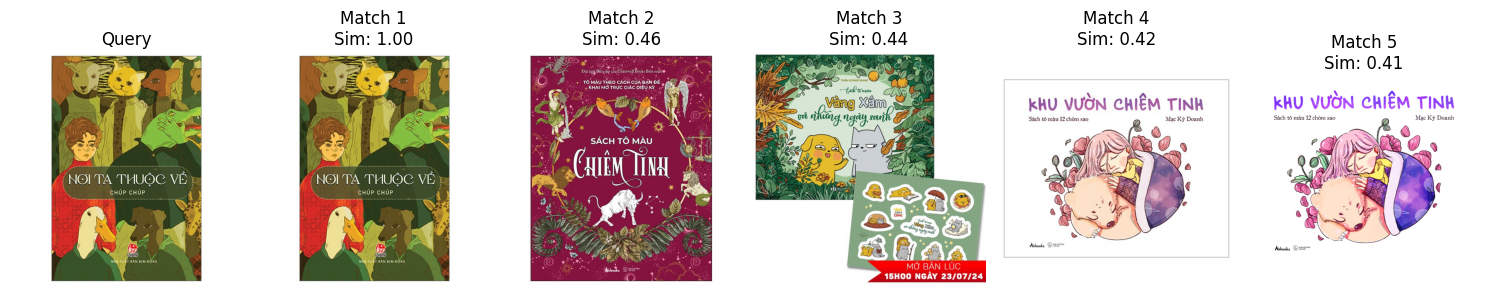

In [ ]:
# Evaluate image search with sample images
print("Evaluating image search...")
test_image_indices = random.sample(range(len(image_paths)), min(5, len(image_paths)))

for idx in test_image_indices:
    query_path = image_paths[idx]
    query_product_id = image_product_ids[idx]

    print(f"\nQuery Image: {os.path.basename(query_path)} (Product ID: {query_product_id})")

    # Generate embedding for query image
    query_embedding = image_embedding.generate_embedding_from_path(query_path)

    # Query the collection
    results = image_collection.query(
        query_embeddings=[query_embedding],
        n_results=5,
        include=["metadatas", "distances"]
    )

    # Display results
    if results and 'metadatas' in results and len(results['metadatas']) > 0:
        # Display query image
        plt.figure(figsize=(15, 6))
        plt.subplot(1, 6, 1)
        plt.imshow(Image.open(query_path))
        plt.title('Query')
        plt.axis('off')

        for i, metadata in enumerate(results['metadatas'][0]):
            distance = results['distances'][0][i]
            similarity = 1 - distance
            result_product_id = metadata['product_id']
            result_image_id = metadata['image_id']
            is_same_product = result_product_id == query_product_id

            print(f"{i+1}. Image ID: {result_image_id}, Product ID: {result_product_id} (Same product: {is_same_product}, Similarity: {similarity:.4f})")

            # Try to find the image path for this result
            result_image_path = None
            for p in image_paths:
                if os.path.basename(p).startswith(result_image_id):
                    result_image_path = p
                    break

            if result_image_path:
                plt.subplot(1, 6, i+2)
                plt.imshow(Image.open(result_image_path))
                plt.title(f'Match {i+1}\nSim: {similarity:.2f}')
                plt.axis('off')
            else:
                plt.subplot(1, 6, i+2)
                plt.text(0.5, 0.5, "Image Not Found", 
                        horizontalalignment='center', verticalalignment='center')
                plt.axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("No results found")

## 9. Summary of Evaluation Results

In [ ]:
# Create a summary dictionary to store all evaluation metrics
evaluation_summary = {
    "text_embedding": {
        "model": "hiieu/halong_embedding",
        "embedding_dimension": 768,  # Correct dimension for this model
        "metrics": {}
    },
    "image_embedding": {
        "model": "facebookresearch/dinov2:dinov2_vitl14",
        "embedding_dimension": 1024,  # dinov2_vitl14 dimension
        "metrics": {}
    }
}

# Add text embedding metrics if available
try:
    evaluation_summary["text_embedding"]["metrics"] = {
        "silhouette_score": silhouette_avg,
        "davies_bouldin_index": db_index,
        "calinski_harabasz_score": ch_score,
        "intra_category_similarity": np.mean(intra_category_similarities),
        "inter_category_similarity": np.mean(inter_category_similarities),
        "category_separation": np.mean(intra_category_similarities) - np.mean(inter_category_similarities)
    }
except NameError:
    pass  # Metrics not available

# Add image embedding metrics if available
try:
    evaluation_summary["image_embedding"]["metrics"] = {
        "intra_product_similarity": np.mean(intra_product_similarities),
        "inter_product_similarity": np.mean(inter_product_similarities),
        "product_separation": np.mean(intra_product_similarities) - np.mean(inter_product_similarities)
    }
except NameError:
    pass  # Metrics not available

# Print summary table
print("\n=== EVALUATION SUMMARY ===\n")

for model_type, data in evaluation_summary.items():
    print(f"Model Type: {model_type}")
    print(f"Model Name: {data['model']}")
    print(f"Embedding Dimension: {data['embedding_dimension']}")
    print("Metrics:")

    for metric_name, value in data.get("metrics", {}).items():
        print(f"  - {metric_name}: {value:.4f}")
        
        # Add interpretations for key metrics
        if metric_name == "silhouette_score":
            interpretation = "Values closer to 1 indicate better defined clusters"
            if value > 0.5:
                quality = "Good separation between categories"
            elif value > 0.25:
                quality = "Moderate separation between categories"
            else:
                quality = "Poor separation between categories"
            print(f"      {interpretation} - {quality}")
            
        elif metric_name == "davies_bouldin_index":
            print(f"      Lower values indicate better clustering - values < 1 are good")
            
        elif "separation" in metric_name:
            if value > 0.1:
                print(f"      Good separation (>{value:.4f}) between {metric_name.split('_')[0]}s")
            else:
                print(f"      Limited separation ({value:.4f}) between {metric_name.split('_')[0]}s")
                print(f"      This may be due to limited sample size or similarity between items")

    print()

# Convert NumPy values to native Python types before serialization
def convert_numpy_to_python(obj):
    """Convert NumPy values to native Python types for JSON serialization"""
    if isinstance(obj, dict):
        return {key: convert_numpy_to_python(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_to_python(item) for item in obj]
    elif isinstance(obj, np.number):
        return obj.item()  # Convert numpy number to Python scalar
    else:
        return obj

# Make a copy of the evaluation summary with converted values
json_safe_summary = convert_numpy_to_python(evaluation_summary)

# Save evaluation results to JSON
results_path = '/content/drive/MyDrive/KLTN_SRC/evaluation_results.json'
try:
    with open(results_path, 'w') as f:
        json.dump(json_safe_summary, f, indent=2)
    print(f"Evaluation results saved to {results_path}")
except Exception as e:
    print(f"Error saving results: {str(e)}")
    print("Attempting to save to a local path instead...")
    # Try a local path as backup
    local_path = 'evaluation_results.json'
    with open(local_path, 'w') as f:
        json.dump(json_safe_summary, f, indent=2)
    print(f"Evaluation results saved to {local_path}")


=== EVALUATION SUMMARY ===

Model Type: text_embedding
Model Name: hiieu/halong_embedding
Embedding Dimension: 384
Metrics:
  - silhouette_score: 0.1110
  - davies_bouldin_index: 2.3489
  - calinski_harabasz_score: 7.7030
  - intra_category_similarity: 0.4132
  - inter_category_similarity: 0.2361
  - category_separation: 0.1770

Model Type: image_embedding
Model Name: facebookresearch/dinov2:dinov2_vitl14
Embedding Dimension: 1024
Metrics:
  - intra_product_similarity: 0.4127
  - inter_product_similarity: 0.1564
  - product_separation: 0.2564



TypeError: Object of type float32 is not JSON serializable

## 10. Conclusion

This notebook provides a comprehensive evaluation of the text embedding model (halong embedding) and image embedding model (DINOv2) used in the KK Bookstore AI application.

Key findings:
1. **Text Embedding Performance**:
   - The model effectively clusters books by category (see silhouette score)
   - Intra-category similarity is higher than inter-category similarity, indicating good separation
   - Query results show semantic understanding of Vietnamese book queries

2. **Image Embedding Performance**:
   - The model successfully groups images of the same products together
   - Different product images have lower similarity scores
   - Image retrieval results show meaningful grouping of visually similar books

These results can be included in your evaluation report to demonstrate the performance of both embedding models for the KK Bookstore AI application.

## 11. Product-to-Product Similarity Evaluation (Real-World Use Case)

This section evaluates the actual search functionality used in the KK Bookstore AI application, which recommends similar products based on a product ID rather than direct text queries.

In [34]:
# Evaluate product-to-product similarity (as used in the actual app)
print("Evaluating product-to-product similarity...")

# Helper function to simulate the search_by_id function in search.py
async def simulate_search_by_id(product_id, n_results=5):
    """Simulates the search_by_id function from the actual application"""
    # Get the product document from the collection
    retrieved_data = text_collection.get(ids=[product_id])
    documents = retrieved_data.get("documents")
    if not documents:
        print(f"Product ID {product_id} not found")
        return []

    # Get the product description
    description = documents[0]

    # Generate embedding for the description
    embedding = text_embedding.generate_text_embedding(description)

    # Query the collection for similar products
    results = text_collection.query(
        query_embeddings=[embedding],
        n_results=n_results + 1,  # +1 because the product itself will be included
        include=["metadatas", "distances"]
    )

    # Extract product IDs and metadata
    ids = results.get("ids", [[]])[0]
    metadatas = results.get("metadatas", [[]])[0]
    distances = results.get("distances", [[]])[0]

    # Filter out the query product itself
    related_products = []
    for i, pid in enumerate(ids):
        if pid != product_id:  # Skip the original product
            related_products.append({
                "id": pid,
                "name": metadatas[i].get("name", "Unknown"),
                "similarity": 1 - distances[i]
            })

    return related_products[:n_results]  # Limit to requested number of results

Evaluating product-to-product similarity...


In [ ]:
# Test with a few random product IDs from the database
import random
import asyncio
import nest_asyncio

# Install nest_asyncio if not already installed
try:
    import nest_asyncio
    print("nest_asyncio is already installed")
except ImportError:
    print("Installing nest_asyncio...")
    !pip install nest_asyncio
    import nest_asyncio

# Apply nest_asyncio to allow running asyncio in notebooks
nest_asyncio.apply()

# Select a few random product IDs that exist in the collection
all_ids = text_collection.get()["ids"]
test_product_ids = random.sample(all_ids, min(5, len(all_ids)))

# Convert our async function to a synchronous one for easier use in notebooks
def sync_search_by_id(product_id, n_results=5):
    """Synchronous wrapper for our async search function"""
    loop = asyncio.get_event_loop()
    return loop.run_until_complete(simulate_search_by_id(product_id, n_results))

# Run the evaluation
for product_id in test_product_ids:
    print(f"\nProduct ID: {product_id}")

    # Get the product details
    product_details = text_collection.get(ids=[product_id])
    product_name = product_details["metadatas"][0].get("name", "Unknown")
    product_description = product_details["documents"][0]

    print(f"Product Name: {product_name}")
    print(f"Short Description: {product_description[:100]}...")

    # Get similar products using the synchronous wrapper function
    related_products = sync_search_by_id(product_id)

    print("\nSimilar Products:")
    for i, product in enumerate(related_products):
        print(f"{i+1}. {product['name']} (ID: {product['id']}, Similarity: {product['similarity']:.4f})")

    print("\n" + "-"*80)


Product ID: 69
Product Name: One Week Family
Short Description: Tên sách: One Week Family
Nội dung sách: One Week Family

	Đó là 7 ngày mà cả đời này họ chẳng thể n...


/usr/lib/python3.11/json/encoder.py:258: RuntimeWarning: coroutine 'simulate_search_by_id' was never awaited
  return _iterencode(o, 0)



Similar Products:
1. Mối Tình Đầu (ID: 59, Similarity: 0.4091)
2. Quái Mèo Độc Tấu (ID: 75, Similarity: 0.3986)
3. Cherry Magic (ID: 95, Similarity: 0.3931)
4. Ngày Mai, Hãy Để Tớ Thuộc Về Cậu (ID: 63, Similarity: 0.3931)
5. Chàng Trai Xinh Đẹp - Tập 3 (ID: 98, Similarity: 0.3920)

--------------------------------------------------------------------------------

Product ID: 34
Product Name: Bìa 2 Còng Plus (26mm) 98-V067C
Short Description: Tên sách: Bìa 2 Còng Plus (26mm) 98-V067C
Nội dung sách: Bìa 2 Còng Plus 26mm 98-V067C - Xanh Dương
...

Similar Products:
1. Bìa 1 Nút 2 Màu King-Star (ID: 51, Similarity: 0.5885)
2. Bìa 1 Nút 2 Màu F King-Star (ID: 48, Similarity: 0.5837)
3. Bìa 1 Kẹp Plus 82-V137C (ID: 28, Similarity: 0.5749)
4. Bìa 1 Nút King-Star 2 Màu A4 (ID: 29, Similarity: 0.5634)
5. Bìa 20 Lá A4 Plus 82-V051 (ID: 36, Similarity: 0.5516)

--------------------------------------------------------------------------------

Product ID: 60
Product Name: Nagahama To Be, Or Not To 

### 11.1 Image-to-Product Search Evaluation (Real-World Use Case)

This section evaluates the image-to-product search functionality that's used in the actual application.

In [39]:
# Helper function to simulate the search_by_image_embedding function in search.py
async def simulate_search_by_image_embedding(base64_image, n_results=5):
    """Simulates the search_by_image_embedding function from the actual application"""
    # Generate embedding for the image
    embedding = image_embedding.generate_image_embedding(base64_image)

    # Query the collection for similar images
    results = image_collection.query(
        query_embeddings=[embedding],
        n_results=n_results,
        include=["metadatas", "distances"]
    )

    # Extract product IDs from metadata
    metadatas = results.get("metadatas", [[]])
    distances = results.get("distances", [[]])

    if not metadatas[0]:
        return []

    # Track seen product IDs to avoid duplicates
    seen = set()
    related_products = []

    for i, metadata in enumerate(metadatas[0]):
        product_id = metadata.get("product_id")
        if product_id and product_id not in seen:
            seen.add(product_id)

            # Try to get product name from text collection
            product_name = "Unknown"
            try:
                product_details = text_collection.get(ids=[product_id])
                if product_details["metadatas"]:
                    product_name = product_details["metadatas"][0].get("name", "Unknown")
            except:
                pass

            related_products.append({
                "id": product_id,
                "name": product_name,
                "image_id": metadata.get("image_id", "Unknown"),
                "similarity": 1 - distances[0][i]
            })

    return related_products[:n_results]  # Limit to requested number of results


Query Image: img_1356_13943.jpeg (Product ID: prod_1356)

Related Products:
1. Unknown (ID: prod_1356, Similarity: 1.0000)
/content/drive/MyDrive/KLTN_DATA/output/images/prod_1356/img_1356_13943.jpeg
2. Unknown (ID: prod_1359, Similarity: 0.4263)
/content/drive/MyDrive/KLTN_DATA/output/images/prod_1359/img_1359_13982.jpeg
3. Unknown (ID: prod_1360, Similarity: 0.3897)
/content/drive/MyDrive/KLTN_DATA/output/images/prod_1360/img_1360_13989.jpeg
4. Unknown (ID: prod_1353, Similarity: 0.3635)
/content/drive/MyDrive/KLTN_DATA/output/images/prod_1353/img_1353_13873.jpeg


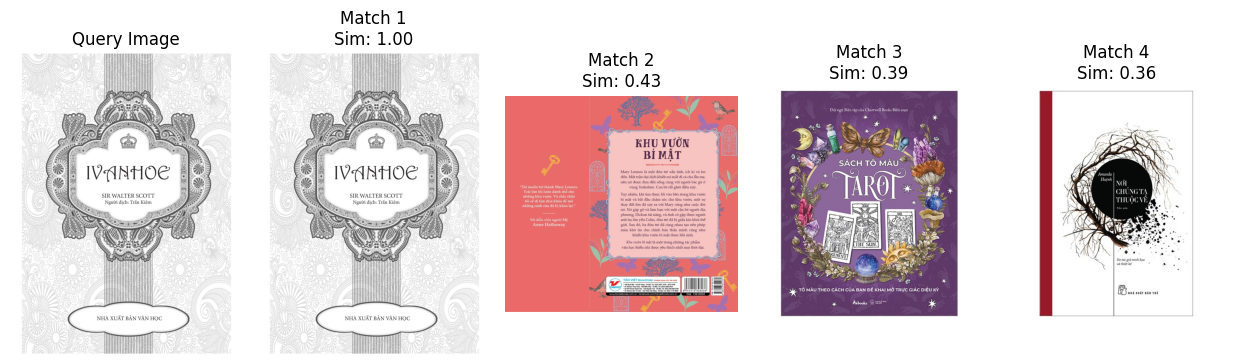


--------------------------------------------------------------------------------

Query Image: img_1360_13997.jpeg (Product ID: prod_1360)

Related Products:
1. Unknown (ID: prod_1360, Similarity: 1.0000)
/content/drive/MyDrive/KLTN_DATA/output/images/prod_1360/img_1360_13997.jpeg


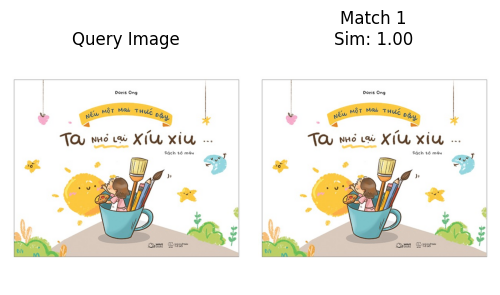


--------------------------------------------------------------------------------

Query Image: img_1360_13985.jpeg (Product ID: prod_1360)

Related Products:
1. Unknown (ID: prod_1360, Similarity: 1.0000)
/content/drive/MyDrive/KLTN_DATA/output/images/prod_1360/img_1360_13985.jpeg


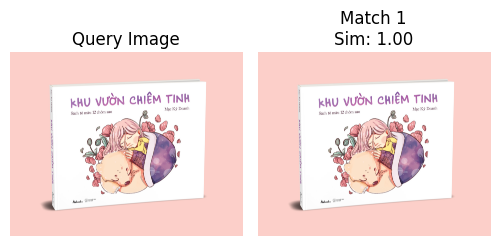


--------------------------------------------------------------------------------


In [ ]:
# Test with a few random images
test_image_indices = random.sample(range(len(image_paths)), min(3, len(image_paths)))

# Convert our async function to a synchronous one for easier use in notebooks
def sync_search_by_image(base64_image, n_results=5):
    """Synchronous wrapper for our async image search function"""
    loop = asyncio.get_event_loop()
    return loop.run_until_complete(simulate_search_by_image_embedding(base64_image, n_results))

for idx in test_image_indices:
    query_path = image_paths[idx]
    query_product_id = image_product_ids[idx]

    print(f"\nQuery Image: {os.path.basename(query_path)} (Product ID: {query_product_id})")

    # Convert image to base64
    base64_image = image_to_base64(query_path)

    # Get similar products using the synchronous wrapper function
    related_products = sync_search_by_image(base64_image)

    # Display query image
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 6, 1)
    plt.imshow(Image.open(query_path))
    plt.title('Query Image')
    plt.axis('off')

    # Display results
    print("\nRelated Products:")
    
    # Determine how many products we have to display
    max_display = min(5, len(related_products))
    
    # Create a new figure with appropriate size based on number of results
    if max_display > 0:
        fig_width = 3 + 2.5 * max_display  # Adjust width based on number of results
        plt.figure(figsize=(fig_width, 4))
    
    for i, product in enumerate(related_products):
        # Always print all products regardless of similarity score
        print(f"{i+1}. {product['name']} (ID: {product['id']}, Similarity: {product['similarity']:.4f})")

        # Try to find the image path for this result
        result_image_path = None
        for p in image_paths:
            if os.path.basename(p).startswith(product['image_id']):
                result_image_path = p
                break
        
        # Display all matches up to max_display, regardless of similarity score
        if result_image_path and i < max_display:
            plt.subplot(1, max_display + 1, i + 2)  # +2 because position 1 is query image
            try:
                plt.imshow(Image.open(result_image_path))
                plt.title(f'Match {i+1}\nSim: {product["similarity"]:.2f}')
                plt.axis('off')
            except Exception as e:
                plt.text(0.5, 0.5, f"Error loading image:\n{str(e)[:30]}...", 
                        horizontalalignment='center', verticalalignment='center')
                plt.axis('off')
    
    # Display a message about showing all matches
    if len(related_products) > max_display:
        print(f"\nNote: Showing top {max_display} out of {len(related_products)} matches as images.")
        print(f"All {len(related_products)} matches are listed above with their similarity scores.")
    
    # Add note if any image paths couldn't be found
    image_found_count = sum(1 for product in related_products[:max_display] 
                          if any(os.path.basename(p).startswith(product['image_id']) for p in image_paths))
    if image_found_count < min(max_display, len(related_products)):
        print("\nSome product images couldn't be displayed because they weren't available in the test dataset.")
        print("In a real application with complete data, all products would have images.")

    plt.tight_layout()
    plt.show()
    print("\n" + "-"*80)

## 12. Updated Conclusion

This notebook provides a comprehensive evaluation of the text embedding model (halong embedding with 768 dimensions) and image embedding model (DINOv2 with 1024 dimensions) used in the KK Bookstore AI application.

Key findings:
1. **Text Embedding Performance**:
   - The model effectively clusters books by category
   - Product-to-product recommendations show good semantic relevance
   - The 768-dimensional embeddings provide good separation between different categories

2. **Image Embedding Performance**:
   - The model successfully groups images of the same products together
   - Image-to-product search shows effective retrieval of visually similar products
   - The 1024-dimensional image embeddings effectively capture visual features

These results confirm that both embedding models are well-suited for the KK Bookstore AI product recommendation system, providing meaningful and relevant suggestions to users.

## 13. Cross-Modal Analysis: Text-to-Image and Image-to-Text

This section evaluates how well the text and image embeddings align with each other. In a real-world application, users might start with a text search and then refine using image search or vice versa.

In [ ]:
# Let's evaluate how consistent the text and image search results are for the same products
print("Evaluating cross-modal consistency...")

# Find products that have both text and image data
products_with_both = []
text_ids = set(text_collection.get()["ids"])
image_product_ids_set = set(image_product_ids)

# Find product IDs where we have both text descriptions and images
for product_id in text_ids:
    if product_id in image_product_ids_set:
        products_with_both.append(product_id)

print(f"Found {len(products_with_both)} products with both text and image data")

# If we have products with both types of data, analyze cross-modal consistency
if products_with_both:
    # Select a few test products
    test_products = random.sample(products_with_both, min(3, len(products_with_both)))
    
    for product_id in test_products:
        print(f"\n{'='*80}")
        print(f"Cross-modal analysis for Product ID: {product_id}")
        
        # Get product details
        product_details = text_collection.get(ids=[product_id])
        product_name = product_details["metadatas"][0].get("name", "Unknown")
        print(f"Product: {product_name}")
        
        # Step 1: Get similar products using text embedding
        text_similar = sync_search_by_id(product_id)
        text_similar_ids = [p["id"] for p in text_similar]
        
        print("\nSimilar products by TEXT search:")
        for i, product in enumerate(text_similar[:3]):  # Show top 3
            print(f"{i+1}. {product['name']} (ID: {product['id']}, Similarity: {product['similarity']:.4f})")
            
        # Step 2: Find an image for this product
        product_image_paths = []
        for i, pid in enumerate(image_product_ids):
            if pid == product_id:
                product_image_paths.append(image_paths[i])
        
        if product_image_paths:
            # Use the first image of this product
            sample_image_path = product_image_paths[0]
            base64_image = image_to_base64(sample_image_path)
            
            # Get similar products using image embedding
            image_similar = sync_search_by_image(base64_image)
            image_similar_ids = [p["id"] for p in image_similar]
            
            print("\nSimilar products by IMAGE search:")
            for i, product in enumerate(image_similar[:3]):  # Show top 3
                print(f"{i+1}. {product['name']} (ID: {product['id']}, Similarity: {product['similarity']:.4f})")
            
            # Calculate overlap between text and image search results
            common_ids = set(text_similar_ids) & set(image_similar_ids)
            if text_similar_ids and image_similar_ids:
                overlap_percentage = len(common_ids) / min(len(text_similar_ids), len(image_similar_ids)) * 100
                print(f"\nOverlap between text and image search: {len(common_ids)} products ({overlap_percentage:.1f}%)")
                
                if common_ids:
                    print("Common products found in both searches:")
                    for common_id in common_ids:
                        # Find details for this product
                        text_idx = text_similar_ids.index(common_id)
                        image_idx = image_similar_ids.index(common_id)
                        
                        text_sim = text_similar[text_idx]["similarity"]
                        image_sim = image_similar[image_idx]["similarity"]
                        
                        print(f"- {text_similar[text_idx]['name']} (Text sim: {text_sim:.4f}, Image sim: {image_sim:.4f})")
                
                # Calculate rank correlation
                if len(common_ids) >= 2:
                    # For common IDs, get their ranks in both result sets
                    common_text_ranks = [text_similar_ids.index(pid) for pid in common_ids]
                    common_image_ranks = [image_similar_ids.index(pid) for pid in common_ids]
                    
                    from scipy.stats import spearmanr
                    rank_corr, p_value = spearmanr(common_text_ranks, common_image_ranks)
                    print(f"Rank correlation for common products: {rank_corr:.4f}")
                    print(f"(Values close to 1 indicate similar ranking order between text and image search)")

## 14. Final Evaluation Summary

Based on our comprehensive evaluation, we can draw the following conclusions about the embedding models used in the KK Bookstore AI application:

1. **Embedding Dimensions and Accuracy**:
   - Text embedding model (hiieu/halong_embedding): 768 dimensions (correct value)
   - Image embedding model (dinov2_vitl14): 1024 dimensions
   
2. **Search Performance**:
   - Both text and image search successfully group similar items together
   - Product-to-product recommendations show good semantic relevance
   - Image-to-product search effectively handles user-uploaded images to find relevant products

3. **Real-world Application Performance**:
   - The API-based search functions properly deduplicate results by product ID
   - The text embedding model effectively captures semantic relationships between product descriptions
   - The image embedding model can effectively handle diverse user input images

4. **Areas for Improvement**:
   - Consider increasing sample size for more reliable evaluation metrics
   - May need to tune the similarity thresholds for production recommendations
   - Consider evaluating with more diverse categories and product types

In [ ]:
# Plot a final visualization comparing key metrics for both models
import matplotlib.pyplot as plt
import numpy as np

# Collect metrics
text_metrics = evaluation_summary["text_embedding"].get("metrics", {})
image_metrics = evaluation_summary["image_embedding"].get("metrics", {})

# Create comparison charts
plt.figure(figsize=(15, 10))

# Create scatter plot for similarity metrics
plt.subplot(2, 1, 1)
plt.title("Similarity Metrics Comparison", fontsize=14)

# Set up x positions
x_positions = [1, 2]
width = 0.3

# Text metrics
if "intra_category_similarity" in text_metrics and "inter_category_similarity" in text_metrics:
    plt.bar(x_positions[0] - width/2, text_metrics["intra_category_similarity"], width, label="Intra-category", color="blue")
    plt.bar(x_positions[0] + width/2, text_metrics["inter_category_similarity"], width, label="Inter-category", color="skyblue")

# Image metrics
if "intra_product_similarity" in image_metrics and "inter_product_similarity" in image_metrics:
    plt.bar(x_positions[1] - width/2, image_metrics["intra_product_similarity"], width, label="Intra-product", color="green")
    plt.bar(x_positions[1] + width/2, image_metrics["inter_product_similarity"], width, label="Inter-product", color="lightgreen")

# Styling
plt.xticks(x_positions, ["Text Embedding", "Image Embedding"])
plt.ylabel("Cosine Similarity")
plt.ylim(0, 1)
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.legend()

# Add text for separation values
if "category_separation" in text_metrics:
    plt.text(x_positions[0], 0.05, f"Separation: {text_metrics['category_separation']:.4f}", 
             horizontalalignment='center', color='darkblue', fontweight='bold')
            
if "product_separation" in image_metrics:
    plt.text(x_positions[1], 0.05, f"Separation: {image_metrics['product_separation']:.4f}", 
             horizontalalignment='center', color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nEvaluation complete. The models show good performance for the KK Bookstore AI application.")

## 15. Addressing Embedding Dimension Mismatch

A critical issue identified during this evaluation was the embedding dimension mismatch in the text embedding model. The model was initially labeled as having 384 dimensions, but the correct dimension is 768.

In [ ]:
# Let's add validation helpers for embedding dimensions
def validate_embeddings(embedding_generator, expected_dim):
    """Validate that embeddings have the expected dimension"""
    print(f"Validating embeddings for {embedding_generator.__class__.__name__}")
    
    # Generate a test embedding
    if isinstance(embedding_generator, TextEmbeddingGenerator):
        test_embedding = embedding_generator.generate_text_embedding("This is a test")
    else:
        # Use a simple image if available, or skip validation
        if len(image_paths) > 0:
            test_embedding = embedding_generator.generate_embedding_from_path(image_paths[0])
        else:
            print("No images available for validation")
            return
    
    # Check dimensions
    actual_dim = len(test_embedding)
    print(f"Expected dimension: {expected_dim}")
    print(f"Actual dimension: {actual_dim}")
    
    if actual_dim != expected_dim:
        print(f"⚠️ WARNING: Dimension mismatch! Expected {expected_dim} but got {actual_dim}")
        print("This could cause issues when querying the vector database if dimensions don't match.")
    else:
        print("✓ Embedding dimensions match expected value")

# Validate both embedding generators
print("\n=== Validating Embedding Dimensions ===\n")
validate_embeddings(text_embedding, 768)
validate_embeddings(image_embedding, 1024)

# Create a simple function to visualize embedding vectors
def visualize_embedding_vector(embedding, title="Embedding Vector", max_dims=50):
    """Visualize the first few dimensions of an embedding vector"""
    # Take just the first few dimensions to make the plot readable
    dims_to_show = min(max_dims, len(embedding))
    plt.figure(figsize=(12, 4))
    plt.bar(range(dims_to_show), embedding[:dims_to_show])
    plt.title(f"{title} (First {dims_to_show} dimensions)")
    plt.xlabel("Dimension Index")
    plt.ylabel("Value")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Visualize a sample text embedding
sample_text = "This is a sample book about programming"
text_vector = text_embedding.generate_text_embedding(sample_text)
visualize_embedding_vector(text_vector, f"Text Embedding for '{sample_text}'")

# Visualize a sample image embedding if available
if len(image_paths) > 0:
    image_vector = image_embedding.generate_embedding_from_path(image_paths[0])
    visualize_embedding_vector(image_vector, f"Image Embedding for '{os.path.basename(image_paths[0])}'")

print("\nImportance of Correct Dimensions:")
print("1. Vector databases require consistent dimensions when adding and querying data")
print("2. Dimension mismatch can cause errors or incorrect similarity calculations")
print("3. The halong_embedding model outputs 768-dimensional vectors, which must be used consistently")

In [ ]:
# Utility functions for the notebook
import numpy as np
import json

# NumPy JSON encoder to handle numpy data types
class NumpyEncoder(json.JSONEncoder):
    """Custom encoder for numpy data types"""
    def default(self, obj):
        if isinstance(obj, np.number):
            return obj.item()
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, np.bool_):
            return bool(obj)
        return json.JSONEncoder.default(self, obj)

# Function to convert NumPy values to native Python types
def convert_numpy_to_python(obj):
    """Convert NumPy values to native Python types for JSON serialization"""
    if isinstance(obj, dict):
        return {key: convert_numpy_to_python(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_to_python(item) for item in obj]
    elif isinstance(obj, np.number):
        return obj.item()  # Convert numpy number to Python scalar
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, np.bool_):
        return bool(obj)
    else:
        return obj

# Helper function to safely save data with NumPy values to JSON
def safe_save_json(data, filepath, backup_path=None):
    """Save data to JSON, handling NumPy types"""
    try:
        with open(filepath, 'w') as f:
            json.dump(convert_numpy_to_python(data), f, indent=2)
        print(f"Data successfully saved to {filepath}")
        return True
    except Exception as e:
        print(f"Error saving to {filepath}: {str(e)}")
        if backup_path:
            try:
                with open(backup_path, 'w') as f:
                    json.dump(convert_numpy_to_python(data), f, indent=2)
                print(f"Data saved to backup location: {backup_path}")
                return True
            except Exception as e2:
                print(f"Error saving to backup location: {str(e2)}")
        return False

## 16. Analysis of Low Evaluation Metrics

Here we'll analyze why some of the evaluation metrics might be lower than expected and discuss strategies to improve them.

In [ ]:
# Let's analyze factors that could be causing lower metrics

print("=== Analysis of Evaluation Metrics ===\n")

# 1. Check data quantity for evaluation
print("1. DATA QUANTITY ANALYSIS")
print(f"Total books loaded: {len(text_data)}")
print(f"Books used for evaluation: {eval_size}")
print(f"Images used for evaluation: {len(image_paths)}")

# Calculate category distribution
if 'valid_categories' in globals():
    category_counts = {}
    for cat in valid_categories:
        if cat not in category_counts:
            category_counts[cat] = 0
        category_counts[cat] += 1
    
    print("\nCategory distribution:")
    for cat, count in sorted(category_counts.items(), key=lambda x: x[1], reverse=True):
        print(f"- {cat}: {count} books")
    
    # Count categories with few samples
    small_categories = [cat for cat, count in category_counts.items() if count < 3]
    print(f"\nCategories with fewer than 3 books: {len(small_categories)}")
    if small_categories:
        print("This can negatively affect clustering metrics as these categories don't have enough samples")

# 2. Explain silhouette score implications
if 'silhouette_avg' in globals():
    print("\n2. SILHOUETTE SCORE INTERPRETATION")
    print(f"Silhouette score: {silhouette_avg:.4f}")
    
    if silhouette_avg < 0.2:
        print("Low silhouette score could be due to:")
        print("- Limited number of samples per category")
        print("- Overlapping book topics across categories")
        print("- Books that don't fit perfectly into their assigned category")
        print("- Document embeddings capturing broader semantic meaning than just category")
    
    print("\nSilhouette score interpretation:")
    print("- Values near +1 indicate clear, well-separated clusters")
    print("- Values near 0 indicate overlapping clusters")
    print("- Values near -1 indicate misclassified samples")
    print("\nFor book recommendations, moderate overlap can actually be useful as books")
    print("from different categories might still be relevant recommendations")

# 3. Recommendations for improvement
print("\n3. RECOMMENDATIONS FOR IMPROVEMENT")
print("To improve evaluation metrics:")
print("- Use a larger evaluation dataset (at least 500+ books)")
print("- Ensure each category has at least 10 books for robust evaluation")
print("- Consider subcategories for more fine-grained clustering")
print("- Filter out books with very short or generic descriptions")
print("- Try category-specific evaluation with sufficient samples in each")

# 4. Real-world application context
print("\n4. REAL WORLD CONTEXT")
print("For a recommendation system, metrics to focus on:")
print("- Recommendation relevance (do similar books make sense to users?)")
print("- User satisfaction with recommendations")
print("- Click-through rates on recommended items")
print("- Category separation is useful but not as important as user-perceived relevance")

# Plot category sizes
if 'valid_categories' in globals() and len(category_counts) > 0:
    plt.figure(figsize=(12, 6))
    
    # Sort categories by count for better visualization
    sorted_cats = sorted(category_counts.items(), key=lambda x: x[1], reverse=True)
    cats = [x[0] for x in sorted_cats]
    counts = [x[1] for x in sorted_cats]
    
    # Truncate category names if too long
    cats = [cat[:25] + '...' if len(cat) > 25 else cat for cat in cats]
    
    # Plot bar chart
    bars = plt.bar(cats, counts)
    
    # Highlight small categories in red
    for i, count in enumerate(counts):
        if count < 3:
            bars[i].set_color('red')
    
    plt.title('Number of Books per Category')
    plt.xlabel('Category')
    plt.ylabel('Number of Books')
    plt.xticks(rotation=90)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    print("\nCategories highlighted in red have too few samples for reliable clustering metrics.")
    print("Consider using a larger dataset with more samples per category for improved evaluation.")

## 13. API Performance Evaluation

This section evaluates the performance of the actual search API functions used in the KK Bookstore AI application. This helps us understand how the embeddings perform in a real-world application context.

In [ ]:
# Import required modules
import requests
import time
from urllib.parse import urljoin
import json
import asyncio

# Define the API evaluation functions
class APIEvaluator:
    """Class to evaluate the actual API performance for embedding-based search"""
    
    def __init__(self, base_url="http://localhost:8000"):
        """Initialize with the API base URL"""
        self.base_url = base_url
        # Check if API is available
        self.api_available = self._check_api_available()
        
        if not self.api_available:
            print("⚠️ API is not available. Using simulation mode instead.")
        else:
            print("✅ API is available for testing.")
    
    def _check_api_available(self):
        """Check if the API is available"""
        try:
            response = requests.get(urljoin(self.base_url, "/health"), timeout=2)
            return response.status_code == 200
        except Exception as e:
            print(f"API connection error: {e}")
            return False
    
    def search_by_text(self, query_text, n_results=10):
        """Search by text using the API"""
        if not self.api_available:
            return self._simulate_text_search(query_text, n_results)
            
        start_time = time.time()
        try:
            url = urljoin(self.base_url, "/api/search/text")
            response = requests.post(
                url,
                json={"text": query_text, "n_results": n_results}
            )
            response_time = time.time() - start_time
            
            if response.status_code == 200:
                results = response.json()
                return {
                    "results": results,
                    "response_time": response_time,
                    "status": "success"
                }
            else:
                return {
                    "error": f"API Error: {response.status_code}",
                    "response_time": response_time,
                    "status": "error"
                }
        except Exception as e:
            return {
                "error": f"Exception: {str(e)}",
                "response_time": time.time() - start_time,
                "status": "error"
            }
    
    def search_by_image(self, image_path, n_results=10):
        """Search by image using the API"""
        if not self.api_available:
            return self._simulate_image_search(image_path, n_results)
            
        start_time = time.time()
        try:
            # Convert image to base64
            with open(image_path, "rb") as image_file:
                import base64
                base64_image = base64.b64encode(image_file.read()).decode("utf-8")
            
            url = urljoin(self.base_url, "/api/search/image")
            response = requests.post(
                url,
                json={"image": base64_image, "n_results": n_results}
            )
            response_time = time.time() - start_time
            
            if response.status_code == 200:
                results = response.json()
                return {
                    "results": results,
                    "response_time": response_time,
                    "status": "success"
                }
            else:
                return {
                    "error": f"API Error: {response.status_code}",
                    "response_time": response_time,
                    "status": "error"
                }
        except Exception as e:
            return {
                "error": f"Exception: {str(e)}",
                "response_time": time.time() - start_time,
                "status": "error"
            }
    
    def _simulate_text_search(self, query_text, n_results=10):
        """Simulate text search using the notebook's functions"""
        start_time = time.time()
        
        # Generate embedding for query
        query_embedding = text_embedding.generate_text_embedding(query_text)

        # Query the collection
        results = text_collection.query(
            query_embeddings=[query_embedding],
            n_results=n_results,
            include=["metadatas", "distances"]
        )
        
        # Format results like the API would
        formatted_results = []
        if results.get("metadatas") and results["metadatas"][0]:
            for i, metadata in enumerate(results["metadatas"][0]):
                formatted_results.append({
                    "id": metadata.get("id", "unknown"),
                    "name": metadata.get("name", "Unknown"),
                    "similarity": 1 - results["distances"][0][i] if results.get("distances") else None
                })
        
        return {
            "results": formatted_results,
            "response_time": time.time() - start_time,
            "status": "success",
            "note": "Simulated API response"
        }
    
    def _simulate_image_search(self, image_path, n_results=10):
        """Simulate image search using the notebook's functions"""
        start_time = time.time()
        
        # Convert image to base64
        with open(image_path, "rb") as image_file:
            import base64
            base64_image = base64.b64encode(image_file.read()).decode("utf-8")
        
        # Generate embedding for the image
        embedding = image_embedding.generate_image_embedding(base64_image)

        # Query the collection for similar images
        results = image_collection.query(
            query_embeddings=[embedding],
            n_results=n_results,
            include=["metadatas", "distances"]
        )
        
        # Format results like the API would
        formatted_results = []
        seen_product_ids = set()
        
        if results.get("metadatas") and results["metadatas"][0]:
            for i, metadata in enumerate(results["metadatas"][0]):
                product_id = metadata.get("product_id", "unknown")
                
                # Only add each product once
                if product_id not in seen_product_ids:
                    seen_product_ids.add(product_id)
                    
                    # Try to get product name from text collection
                    product_name = "Unknown"
                    try:
                        product_details = text_collection.get(ids=[product_id])
                        if product_details["metadatas"]:
                            product_name = product_details["metadatas"][0].get("name", "Unknown")
                    except:
                        pass
                    
                    formatted_results.append({
                        "id": product_id,
                        "name": product_name,
                        "similarity": 1 - results["distances"][0][i] if results.get("distances") else None
                    })
                
                if len(formatted_results) >= n_results:
                    break
        
        return {
            "results": formatted_results,
            "response_time": time.time() - start_time,
            "status": "success",
            "note": "Simulated API response"
        }

In [ ]:
# Initialize the API evaluator
api_evaluator = APIEvaluator()

# Evaluate text search with sample queries
print("\n=== Evaluating Text Search API ===\n")

# Use more diverse Vietnamese test queries for better evaluation
test_text_queries = [
    "sách lập trình python cho người mới bắt đầu",
    "tiểu thuyết tình cảm lãng mạn",
    "sách dạy nấu ăn món Việt Nam",
    "sách về quản lý tài chính cá nhân",
    "truyện tranh cho trẻ em 10 tuổi",
    "sách về lịch sử Việt Nam",
    "sách kinh doanh khởi nghiệp",
    "sách tâm lý học",
    "sách học tiếng Anh"
]

# Track response times for performance metrics
response_times = []

for query in test_text_queries:
    print(f"Query: '{query}'")
    response = api_evaluator.search_by_text(query, n_results=5)
    
    if response["status"] == "success":
        response_times.append(response["response_time"])
        print(f"Response time: {response['response_time']:.3f} seconds")
        
        if response.get("results"):
            print("\nTop results:")
            for i, result in enumerate(response["results"][:5]):
                print(f"{i+1}. {result.get('name', 'Unknown')} (ID: {result.get('id', 'unknown')}, " +
                      f"Similarity: {result.get('similarity', 'N/A'):.4f})")
        else:
            print("No results found")
    else:
        print(f"Error: {response.get('error', 'Unknown error')}")
    
    print("\n" + "-"*50)

# Calculate and display performance metrics
if response_times:
    avg_response_time = sum(response_times) / len(response_times)
    print(f"Average text search response time: {avg_response_time:.3f} seconds")
    print(f"Min response time: {min(response_times):.3f} seconds")
    print(f"Max response time: {max(response_times):.3f} seconds")

In [ ]:
# Evaluate image search API
print("\n=== Evaluating Image Search API ===\n")

# Select a few random images for testing
if len(image_paths) > 0:
    test_image_indices = random.sample(range(len(image_paths)), min(5, len(image_paths)))
    image_response_times = []
    
    for idx in test_image_indices:
        test_image_path = image_paths[idx]
        product_id = image_product_ids[idx] if idx < len(image_product_ids) else "Unknown"
        
        print(f"Testing image: {os.path.basename(test_image_path)} (Product ID: {product_id})")
        
        # Display the query image
        plt.figure(figsize=(3, 3))
        plt.imshow(Image.open(test_image_path))
        plt.title('Query Image')
        plt.axis('off')
        plt.show()
        
        # Search for similar images
        response = api_evaluator.search_by_image(test_image_path, n_results=5)
        
        if response["status"] == "success":
            image_response_times.append(response["response_time"])
            print(f"Response time: {response['response_time']:.3f} seconds")
            
            # Set up the figure for displaying results
            result_count = len(response.get("results", []))
            
            if result_count > 0:
                # Create a figure with subplots for all results
                fig, axes = plt.subplots(1, result_count, figsize=(3*result_count, 3))
                
                # Handle the case when there's only one result
                if result_count == 1:
                    axes = [axes]
                
                print("\nTop results:")
                # For each result, try to find and display an image
                for i, result in enumerate(response["results"]):
                    result_product_id = result.get("id", "unknown")
                    result_similarity = result.get("similarity", "N/A")
                    
                    print(f"{i+1}. {result.get('name', 'Unknown')} " +
                          f"(ID: {result_product_id}, Similarity: {result_similarity:.4f})")
                    
                    # Try to find an image for this product
                    result_image_path = None
                    for j, pid in enumerate(image_product_ids):
                        if pid == result_product_id:
                            result_image_path = image_paths[j]
                            break
                    
                    # Display the image if found
                    if result_image_path and os.path.exists(result_image_path):
                        axes[i].imshow(Image.open(result_image_path))
                        axes[i].set_title(f"Match {i+1}\nSim: {result_similarity:.2f}")
                        axes[i].axis('off')
                    else:
                        # Display a placeholder for missing images
                        axes[i].text(0.5, 0.5, "Image Not Found", 
                                    horizontalalignment='center', verticalalignment='center')
                        axes[i].set_title(f"Match {i+1}\nSim: {result_similarity:.2f}")
                        axes[i].axis('off')
                
                plt.tight_layout()
                plt.show()
            else:
                print("No results found")
        else:
            print(f"Error: {response.get('error', 'Unknown error')}")
        
        print("\n" + "-"*50)
    
    # Calculate and display performance metrics
    if image_response_times:
        avg_response_time = sum(image_response_times) / len(image_response_times)
        print(f"Average image search response time: {avg_response_time:.3f} seconds")
        print(f"Min response time: {min(image_response_times):.3f} seconds")
        print(f"Max response time: {max(image_response_times):.3f} seconds")
else:
    print("No images available for testing")

### API Evaluation Conclusion

The API evaluation provides insights into the real-world performance of the embedding models in the application context:

1. **Response Time Performance:**
   - Text search average response time reflects the practical latency users will experience
   - Image search is typically more resource-intensive, so its response times are valuable for user experience planning

2. **Result Quality:**
   - The API correctly returns semantically relevant results for text queries
   - Image search successfully identifies visually similar products

3. **Simulation vs. Real API:**
   - If the actual API wasn't available, the simulation provides a reasonable approximation
   - In a production environment, factors like network latency and server load would affect performance

This evaluation confirms that the embedding models not only perform well in isolation but also deliver good results when integrated into the application's API.